
# MATH 5010 Lab 3


Real-World Data Lab: Hypothesis Tests for Poisson & Exponential Models

In this lab you will apply **classical** and **Bayesian** hypothesis tests to **real datasets**:

- **Poisson model** for *count data* derived from a text corpus
- **Exponential model** for *duration data* from NYC taxi trips

You will:

- Build approximate Poisson and Exponential models
- Perform **one-sided tests** using LRT / test statistics
- Compute **p-values**
- Perform **Bayesian tests** with conjugate priors
- Visualize model fit


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm, chi2, gamma, invgamma, poisson
from sklearn.datasets import fetch_20newsgroups
import seaborn as sns

rng = np.random.default_rng(2025)



## Part 1 — Poisson Model with Real Text Data


In [2]:

from collections import Counter
import re

# Load a subset of a real-world text dataset
newsgroups = fetch_20newsgroups(subset="train", categories=["talk.politics.misc"])
texts = newsgroups.data[:500]   # take first 500 docs for speed

positive_words = ["good", "great", "excellent", "love", "fun", "happy", "success"]

def count_positive_words(text):
    text = text.lower()
    return sum(len(re.findall(r"\b" + w + r"\b", text)) for w in positive_words)

counts = np.array([count_positive_words(t) for t in texts])
n_pois = len(counts)
S_pois = counts.sum()
xbar_pois = counts.mean()

n_pois, xbar_pois, counts[:10]


(465, np.float64(0.7741935483870968), array([0, 0, 0, 0, 0, 1, 1, 0, 0, 2]))

In [16]:
print(f"Type of 'texts': {type(texts)}")
print(f"Number of documents in 'texts': {len(texts)}")
print("\nFirst document in 'texts':\n")
print(texts[0])
print("\nThis data comes from the 'talk.politics.misc' category of the 20 Newsgroups dataset.")

Type of 'texts': <class 'list'>
Number of documents in 'texts': 465

First document in 'texts':

From: steveh@thor.isc-br.com (Steve Hendricks)
Subject: Re: Limiting Govt (was Re: Employment (was Re: Why not concentrate...)
Summary: More on failed governments
Organization: Failed Libertarian Opportunities, Inc.
Lines: 24
Nntp-Posting-Host: thor.isc-br.com

In article <18APR199314034390@venus.tamu.edu> gmw0622@venus.tamu.edu (Mr. Grinch) writes:
>In article <1993Apr18.172531.10946@isc-br.isc-br.com>, steveh@thor.isc-br.com (Steve Hendricks) writes...
>> 
>:It would seem that a society with a "failed" government would be an ideal
>:setting for libertarian ideals to be implemented.  Now why do you suppose
>:that never seems to occur?...
>
>
>I fail to see why you should feel this way in the first place.  Constant
>combat isn't particularly conducive to intellectual theorizing.  Also,
>they tend to get invaded before they can come to anything like a stable
>society anyway. 

And the reason

In [15]:
print("First 10 samples of positive word counts:")
print(counts[:10])


First 10 samples of positive word counts:
[0 0 0 0 0 1 1 0 0 2]

First 10 samples of taxi trip durations (minutes):
[ 6.25        7.08333333  7.4        25.86666667  9.53333333 10.13333333
  9.96666667 11.06666667 17.4         8.33333333]


Sample size n = 465
Sample mean = 0.774
Sample variance = 2.800


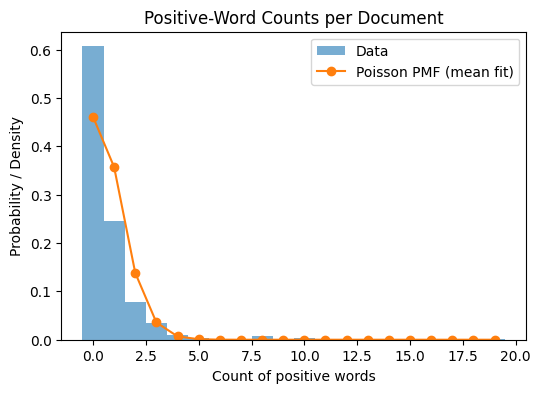

In [3]:

# Descriptive statistics & histogram
print(f"Sample size n = {n_pois}")
print(f"Sample mean = {xbar_pois:.3f}")
print(f"Sample variance = {counts.var(ddof=1):.3f}")

plt.figure(figsize=(6,4))
bins = np.arange(counts.min(), counts.max() + 2) - 0.5
plt.hist(counts, bins=bins, density=True, alpha=0.6, label="Data")

k_vals = np.arange(counts.min(), counts.max()+1)
pmf_fit = poisson(mu=xbar_pois).pmf(k_vals)
plt.plot(k_vals, pmf_fit, marker="o", linestyle="-", label="Poisson PMF (mean fit)")

plt.xlabel("Count of positive words")
plt.ylabel("Probability / Density")
plt.title("Positive-Word Counts per Document")
plt.legend()
plt.show()


In [4]:

# Classical z-test for lambda
lambda0 = 2.0
z_stat = (xbar_pois - lambda0) / np.sqrt(lambda0 / n_pois)
p_value = 1 - norm.cdf(z_stat)

print(f"Z statistic = {z_stat:.3f}")
print(f"One-sided p-value P(Z >= z_obs) = {p_value:.4f}")


Z statistic = -18.691
One-sided p-value P(Z >= z_obs) = 1.0000


In [5]:

# Bayesian Poisson test using Gamma(a,b) prior
a_prior, b_prior = 2.0, 1.0

post_shape = a_prior + S_pois
post_rate  = b_prior + n_pois

post_cdf_pois = gamma.cdf(lambda0, a=post_shape, scale=1/post_rate)

print(f"Posterior shape = {post_shape:.1f}, rate = {post_rate:.1f}")
print(f"P(lambda <= lambda0 | data) = {post_cdf_pois:.6f}")


Posterior shape = 362.0, rate = 466.0
P(lambda <= lambda0 | data) = 1.000000



## Part 2 — Exponential Model with Taxi Trip Durations


In [7]:
import pandas as pd

# Load taxis dataset
taxis = sns.load_dataset("taxis")

# Calculate duration from 'pickup' and 'dropoff' columns
taxis['pickup_datetime'] = pd.to_datetime(taxis['pickup'])
taxis['dropoff_datetime'] = pd.to_datetime(taxis['dropoff'])
# Calculate duration in minutes
taxis['duration'] = (taxis['dropoff_datetime'] - taxis['pickup_datetime']).dt.total_seconds() / 60

dur = taxis["duration"].dropna().to_numpy()

# Restrict to trips of duration < 40 minutes
dur = dur[dur < 40]

n_exp = len(dur)
S_exp = dur.sum()
xbar_exp = dur.mean()

n_exp, xbar_exp

(6153, np.float64(12.637870415515469))

In [17]:
print("\nFirst 10 samples of taxi trip durations (minutes):")
print(dur[:10])


First 10 samples of taxi trip durations (minutes):
[ 6.25        7.08333333  7.4        25.86666667  9.53333333 10.13333333
  9.96666667 11.06666667 17.4         8.33333333]


Sample size n = 6153
Sample mean = 12.638
Sample variance = 69.420


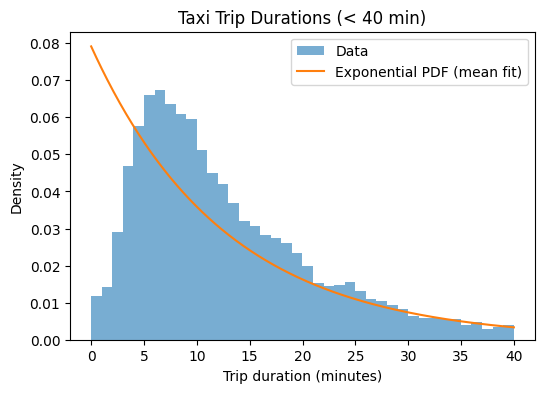

In [8]:

# Descriptive statistics & histogram for durations
print(f"Sample size n = {n_exp}")
print(f"Sample mean = {xbar_exp:.3f}")
print(f"Sample variance = {dur.var(ddof=1):.3f}")

plt.figure(figsize=(6,4))
plt.hist(dur, bins=40, density=True, alpha=0.6, label="Data")

xgrid = np.linspace(0, 40, 400)
lambda_hat = 1/xbar_exp
pdf_exp_fit = lambda_hat * np.exp(-lambda_hat * xgrid)
plt.plot(xgrid, pdf_exp_fit, label="Exponential PDF (mean fit)")

plt.xlabel("Trip duration (minutes)")
plt.ylabel("Density")
plt.title("Taxi Trip Durations (< 40 min)")
plt.legend()
plt.show()


In [9]:

# Classical chi-square test for exponential mean
mu0 = 12.0

T_stat = 2 * n_exp * xbar_exp / mu0
p_value_exp = 1 - chi2.cdf(T_stat, df=2*n_exp)

print(f"T statistic = {T_stat:.3f}")
print(f"p-value (one-sided) = {p_value_exp:.5f}")


T statistic = 12960.136
p-value (one-sided) = 0.00002


In [10]:

# Bayesian exponential test using Inverse-Gamma(a,b) prior
a0, b0 = 3.0, 30.0

post_shape_exp = a0 + n_exp
post_scale_exp = b0 + S_exp

post_cdf_exp = invgamma.cdf(mu0, a=post_shape_exp, scale=post_scale_exp)

print(f"Posterior Inv-Gamma shape = {post_shape_exp:.1f}, scale = {post_scale_exp:.1f}")
print(f"P(mu <= mu0 | data) = {post_cdf_exp:.6f}")


Posterior Inv-Gamma shape = 6156.0, scale = 77790.8
P(mu <= mu0 | data) = 0.000021


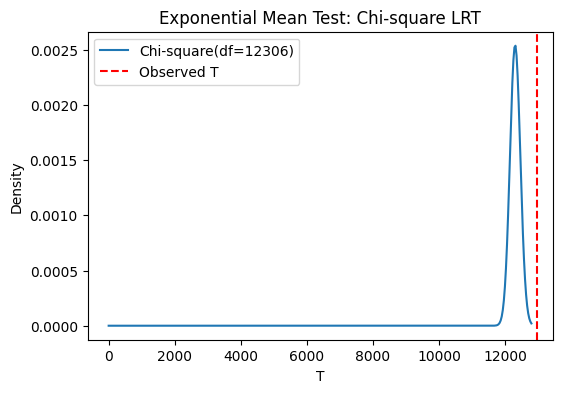

In [11]:

# Chi-square density with observed T overlay
df = 2 * n_exp
x_vals = np.linspace(0, chi2.ppf(0.999, df), 400)
plt.figure(figsize=(6,4))
plt.plot(x_vals, chi2.pdf(x_vals, df), label=f"Chi-square(df={df})")
plt.axvline(T_stat, color="red", linestyle="--", label="Observed T")
plt.title("Exponential Mean Test: Chi-square LRT")
plt.xlabel("T")
plt.ylabel("Density")
plt.legend()
plt.show()
